# Project 1 - Customer Segmentation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data_dir = "/content/drive/MyDrive/InternWeek3Project1_Customers _Segmentation /Mall_Customers.csv"

In [4]:
data = pd.read_csv(data_dir)

In [5]:
print(data.shape)

(200, 5)


In [6]:
print(data.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


summary statistics for all numeric columns



In [9]:
print(data.describe())

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


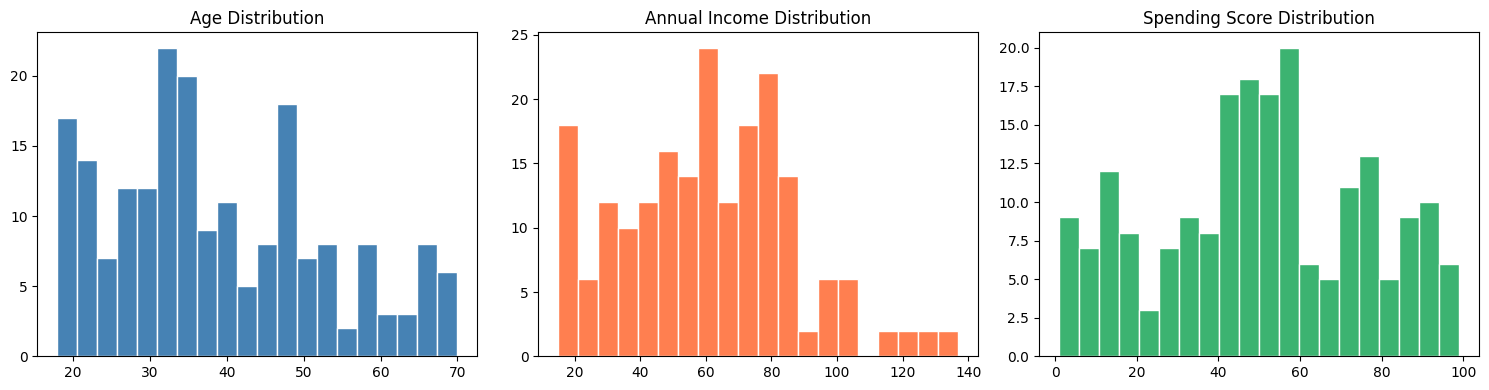

/tmp/ipykernel_4772/2459271143.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Gender', palette='Set2')


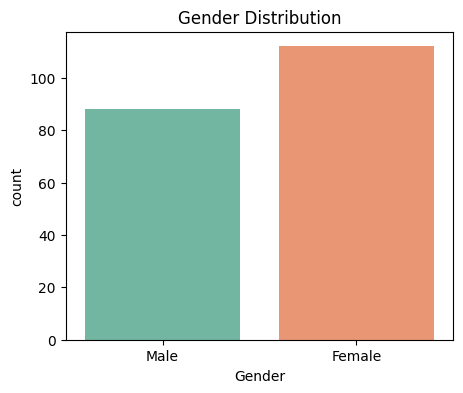

In [10]:
# Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(data['Age'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution')

axes[1].hist(data['Annual Income (k$)'], bins=20, color='coral', edgecolor='white')
axes[1].set_title('Annual Income Distribution')

axes[2].hist(data['Spending Score (1-100)'], bins=20, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Spending Score Distribution')

plt.tight_layout()
plt.show()

# Gender distribution(catogerical data)
plt.figure(figsize=(5, 4))
sns.countplot(data=data, x='Gender', palette='Set2')
plt.title('Gender Distribution')
plt.show()

Label Encoding

In [11]:
data['Gender_encoded'] = data['Gender'].map({'Male': 0, 'Female': 1})

In [12]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Gender_encoded
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,1
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


Remove CustomerID and Gender columns

In [13]:
data_clean = data.drop(['CustomerID', 'Gender'], axis=1)

print(data_clean.head())

   Age  Annual Income (k$)  Spending Score (1-100)  Gender_encoded
0   19                  15                      39               0
1   21                  15                      81               0
2   20                  16                       6               1
3   23                  16                      77               1
4   31                  17                      40               1


In [14]:
from sklearn.preprocessing import StandardScaler

Using Age and Spending Score (1-100) as the profile clusters

In [15]:
features = ['Age', 'Spending Score (1-100)']
X = data_clean[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled features shape:", X_scaled.shape)

Scaled features shape: (200, 2)


In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [17]:
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

Plotting the Elbow

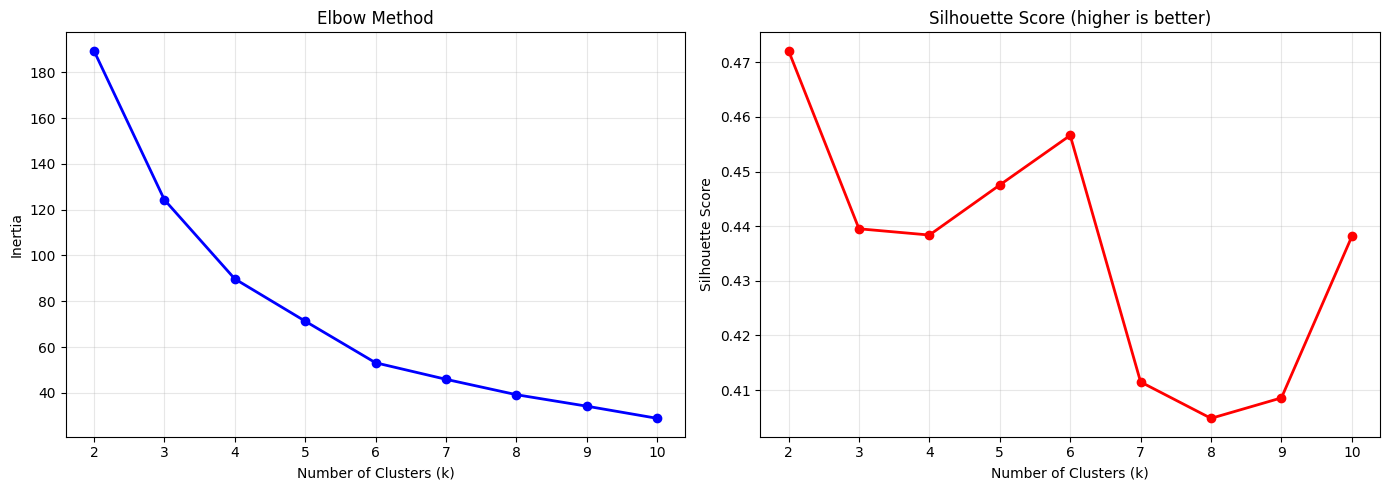


Silhouette Scores:
  k=2: 0.4721
  k=3: 0.4395
  k=4: 0.4384
  k=5: 0.4475
  k=6: 0.4566
  k=7: 0.4115
  k=8: 0.4048
  k=9: 0.4086
  k=10: 0.4381


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertia, 'bo-', linewidth=2, markersize=6)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)

# Plot Silhouette
axes[1].plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=6)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (higher is better)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nSilhouette Scores:")
for k, score in zip(k_range, silhouette_scores):
    print(f"  k={k}: {score:.4f}")

Apply K-Means with optimal k=6

In [19]:
optimal_k = 6

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(X_scaled)

data['Cluster'] = kmeans.labels_
print("Cluster counts:")
print(data['Cluster'].value_counts().sort_index())

Cluster counts:
Cluster
0    25
1    57
2    20
3    23
4    38
5    37
Name: count, dtype: int64


cluster profile summary table:


1.   Number of customers in each
cluster
2.   Average age, income, and spending score
3.Percentage of females in each cluster





In [22]:
profile = data.groupby('Cluster').agg(
    Count        = ('CustomerID', 'count'),
    Avg_Age      = ('Age', 'mean'),
    Avg_Income   = ('Annual Income (k$)', 'mean'),
    Avg_Spending = ('Spending Score (1-100)', 'mean'),
    Female_Pct   = ('Gender_encoded', 'mean')
).round(2)

profile['Female_Pct'] = (profile['Female_Pct'] * 100).round(1)
print(profile)

         Count  Avg_Age  Avg_Income  Avg_Spending  Female_Pct
Cluster                                                      
0           25    33.68       68.64         16.40        44.0
1           57    30.18       66.07         82.35        58.0
2           20    64.85       53.15         49.85        40.0
3           23    52.87       60.35         13.96        52.0
4           38    25.08       52.42         50.47        61.0
5           37    47.08       59.11         45.95        68.0


Name and Interpret clusters

In [23]:
cluster_names = {
    0: 'Young Low Spenders',
    1: 'Young High Spenders',
    2: 'Elderly Moderate Spenders',
    3: 'Middle-Aged Low Spenders',
    4: 'Young Moderate Spenders',
    5: 'Middle-Aged Moderate Spenders'
}

data['Segment'] = data['Cluster'].map(cluster_names)

print(data['Segment'].value_counts())

Segment
Young High Spenders              57
Young Moderate Spenders          38
Middle-Aged Moderate Spenders    37
Young Low Spenders               25
Middle-Aged Low Spenders         23
Elderly Moderate Spenders        20
Name: count, dtype: int64


Segment report with marketing actions

In [24]:
segment_report = {
    'Young High Spenders': {
        'Profile'         : 'Youngest customers (~30), highest spending score (82)',
        'Marketing Action': 'VIP memberships, premium products, exclusive early access deals'
    },
    'Young Low Spenders': {
        'Profile'         : 'Young (~34) but very low spenders (16)',
        'Marketing Action': 'Discount campaigns, budget bundles, incentivize first purchases'
    },
    'Young Moderate Spenders': {
        'Profile'         : 'Youngest group (~25), moderate spending (50)',
        'Marketing Action': 'Loyalty reward programs, trendy product promotions, social media campaigns'
    },
    'Middle-Aged Moderate Spenders': {
        'Profile'         : 'Middle-aged (~47), moderate spending (46)',
        'Marketing Action': 'Family-oriented promotions, seasonal offers, convenience-focused products'
    },
    'Middle-Aged Low Spenders': {
        'Profile'         : 'Older middle-aged (~53), very low spending (14)',
        'Marketing Action': 'Value-for-money deals, essential product bundles, re-engagement campaigns'
    },
    'Elderly Moderate Spenders': {
        'Profile'         : 'Oldest group (~65), moderate spending (50)',
        'Marketing Action': 'Premium comfort products, personalized service, health and wellness promotions'
    }
}

for segment, info in segment_report.items():
    print(f"\n{'='*55}")
    print(f"Segment : {segment}")
    print(f"Profile : {info['Profile']}")
    print(f"Action  : {info['Marketing Action']}")


Segment : Young High Spenders
Profile : Youngest customers (~30), highest spending score (82)
Action  : VIP memberships, premium products, exclusive early access deals

Segment : Young Low Spenders
Profile : Young (~34) but very low spenders (16)
Action  : Discount campaigns, budget bundles, incentivize first purchases

Segment : Young Moderate Spenders
Profile : Youngest group (~25), moderate spending (50)
Action  : Loyalty reward programs, trendy product promotions, social media campaigns

Segment : Middle-Aged Moderate Spenders
Profile : Middle-aged (~47), moderate spending (46)
Action  : Family-oriented promotions, seasonal offers, convenience-focused products

Segment : Middle-Aged Low Spenders
Profile : Older middle-aged (~53), very low spending (14)
Action  : Value-for-money deals, essential product bundles, re-engagement campaigns

Segment : Elderly Moderate Spenders
Profile : Oldest group (~65), moderate spending (50)
Action  : Premium comfort products, personalized service, 

 Visualize clusters

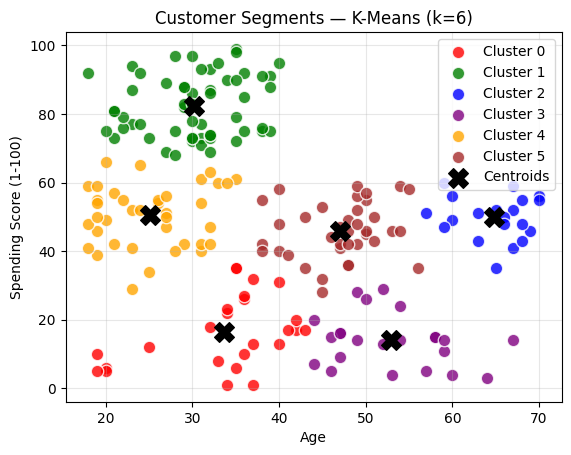

In [25]:
colors = ['red', 'green', 'blue', 'purple', 'orange', 'brown']
for cluster in range(optimal_k):
    mask = data['Cluster'] == cluster
    plt.scatter(
        data.loc[mask, 'Age'],
        data.loc[mask, 'Spending Score (1-100)'],
        c=colors[cluster], label=f'Cluster {cluster}',
        s=80, alpha=0.8, edgecolors='white'
    )

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='black', marker='X', s=200, zorder=5, label='Centroids')

plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments — K-Means (k=6)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_4772/2014573772.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Cluster', y='Age',
/tmp/ipykernel_4772/2014573772.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Cluster', y='Annual Income (k$)',
/tmp/ipykernel_4772/2014573772.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Cluster', y='Spending Score (1-100)',


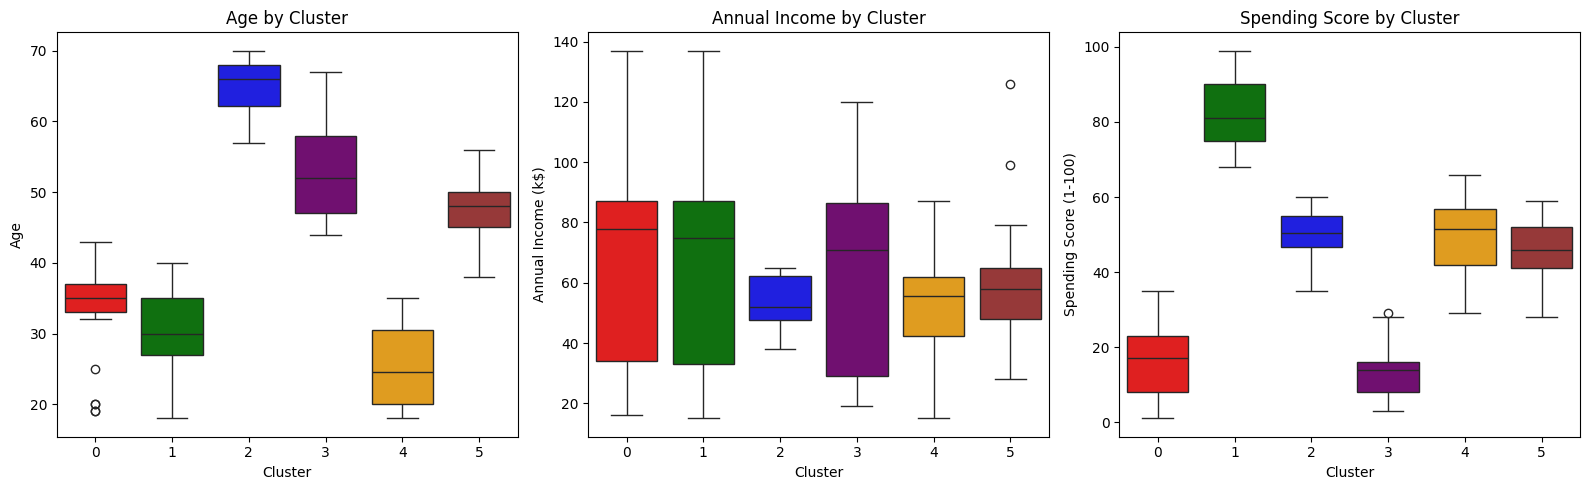

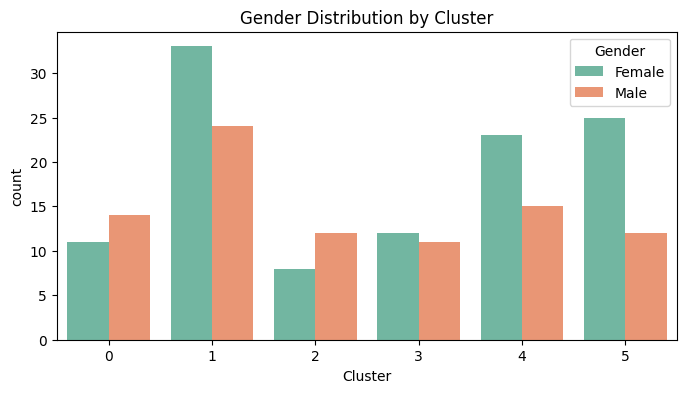

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Age by cluster
sns.boxplot(data=data, x='Cluster', y='Age',
            palette=colors, ax=axes[0])
axes[0].set_title('Age by Cluster')

# Income by cluster
sns.boxplot(data=data, x='Cluster', y='Annual Income (k$)',
            palette=colors, ax=axes[1])
axes[1].set_title('Annual Income by Cluster')

# Spending Score by cluster
sns.boxplot(data=data, x='Cluster', y='Spending Score (1-100)',
            palette=colors, ax=axes[2])
axes[2].set_title('Spending Score by Cluster')

plt.tight_layout()
plt.show()

# Gender distribution per cluster
plt.figure(figsize=(8, 4))
sns.countplot(data=data, x='Cluster', hue='Gender', palette='Set2')
plt.title('Gender Distribution by Cluster')
plt.show()

Save cluster labels & model

In [27]:
import joblib
import warnings
warnings.filterwarnings('ignore')

# Save data with cluster labels
data.to_csv('customer_segments.csv', index=False)

# Save model and scaler
joblib.dump(kmeans,  'kmeans_model.pkl')
joblib.dump(scaler,  'kmeans_scaler.pkl')

print("Cluster labels saved to customer_segments.csv")
print("Model and scaler saved.")

Cluster labels saved to customer_segments.csv
Model and scaler saved.


In [28]:
from google.colab import files

files.download('customer_segments.csv')
files.download('kmeans_model.pkl')
files.download('kmeans_scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>